Model Comparison Performance Table
                       RMSE  R2 Score
Linear Regression  0.745581  0.575788
Ridge Regression   0.745557  0.575816
Decision Tree      0.724234  0.599732
Best Model: Decision Tree
Best RMSE: 0.7242338143386247
Best R² Score: 0.5997321244428706


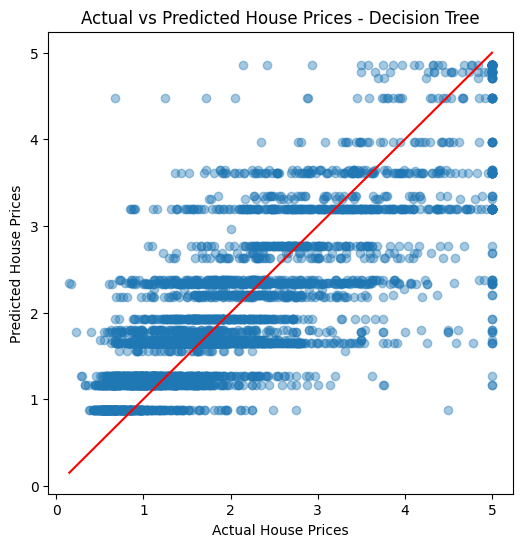

Final Model: Decision Tree
RMSE: 0.724
R² Score: 0.600
Model saved as best_california_housing_model.pkl


In [8]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
# Step 2: Load the dataset
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")],axis=1)
df.head()
# Step 3: Separate features and target variable
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]
# Step 4: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
# Step 5: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Step 6: Train multiple models
models = {"Linear Regression": LinearRegression(),
          "Ridge Regression": Ridge(alpha=1.0),
          "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42)}
# Step 7: Model evaluation and comparison
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    results[name] = {"RMSE": rmse,"R2 Score": r2}
results_df = pd.DataFrame(results).T
print("Model Comparison Performance Table")
print(results_df)
# Step 8: Select the best model based on RMSE
best_model_name = results_df["RMSE"].idxmin()
best_model = models[best_model_name]
print("Best Model:", best_model_name)
print("Best RMSE:", results_df.loc[best_model_name, "RMSE"])
print("Best R² Score:", results_df.loc[best_model_name, "R2 Score"])
# Step 9: Train the selected model and make predictions
best_model.fit(X_train_scaled, y_train)
y_pred = best_model.predict(X_test_scaled)
# Step 10: Visual Performance Validation
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title(f"Actual vs Predicted House Prices - {best_model_name}")
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],color="red")
plt.show()
# Step 11: Final model performance
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_r2 = r2_score(y_test, y_pred)
print("Final Model:", best_model_name)
print(f"RMSE: {final_rmse:.3f}")
print(f"R² Score: {final_r2:.3f}")
# Step 12: Save the selected model
import joblib
joblib.dump(best_model, "best_california_housing_model.pkl")
print("Model saved as best_california_housing_model.pkl")